<a href="https://colab.research.google.com/github/Statofthe7/SentimentAnalysisPolarityBias/blob/main/SentimentAnalysisPolarityBias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt-get update # Up to date list of packages
# !apt-get install -y mecab libmecab-dev # Mecab and its libraries for Fugashi

In [2]:
# Install dependencies
!pip install datasets pandas transformers torch sentencepiece openpyxl --quiet
# !pip install fugashi[unidic-lite]
!pip install anthropic openai google-generativeai --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.4/469.4 kB 8.3 MB/s eta 0:00:00


In [3]:
# Imports
# from fugashi import Tagger
from transformers import AutoTokenizer, pipeline
import warnings
import pandas as pd
from datasets import load_dataset
from tqdm import tqdm # for progress bar
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.metrics import confusion_matrix
from scipy import stats
import numpy as np
import anthropic
import openai
from google import genai
import time
from google.colab import userdata


In [ ]:
# This script loads Amazon Multilingual datasets (French and Japanese)
# Both datasets are Amazon product reviews
# Source: amazon_reviews_multi (Keung et al., 2020) via Hugging Face Datasets
# Load french and japanese parquet files to this project before running the script

# Load from local parquet files
fr_data = pd.read_parquet('/content/fr_test.parquet')
jp_data = pd.read_parquet('/content/ja_test.parquet')

# This part of the script calculates average and maximum "length" of reviews in both datasets
# For French, length is count of words in each review
# For Japanese, lenght is count of morphemes or sub-word tokens

# mDeBERTa-v3 is a multilingual version of DeBERTa (Decoding-enhanced BERT with distangled attention) and is a medium sized pre-trained model
# As part of fine-tuning on mnli and xnli datasets, it has learned to reason about a premise's entailment
# and contradiction to a hypothesis (NLI-Natural Language Inference) across different languages
tokenizer = AutoTokenizer.from_pretrained("MoritzLaurer/mDeBERTa-v3-base-mnli-xnli")

# Setup Japanese Tagger to breakup text into space separated (owakati) morphemes
#tagger = Tagger('-Owakati')

# Get token length in Japanese
def get_japanese_token_length(text):

    # Using fugashi to parse text to morphemes separated by spaces and split to form a list
    # tokens = tagger.parse(text).split()

    # Using the model's native tokenizer (SentencePiece) to parse japanese text to sub-word tokens (similar to morphemes)
    tokens = tokenizer.encode(text)

    return len(tokens)

def get_stats(df, text_column, lang):
    df = pd.DataFrame(df)

    if lang == 'fr':
        # French: Use SentencePiece
        df['length'] = df[text_column].apply(lambda text: len(tokenizer.encode(text)))
    else:
        # Japanese: Split by morphemes using fugashi or sub-word tokens using SentencePiece
        df['length'] = df[text_column].apply(get_japanese_token_length)

    return df['length'].mean(), df['length'].max()

fr_mean, fr_max = get_stats(fr_data, 'text', 'fr')
jp_mean, jp_max = get_stats(jp_data, 'text', 'jp')

print(f"\n--- Statistical Results ---")
print(f"French   - Avg Tokens per Review: {fr_mean:.2f} (Max: {fr_max})")
print(f"Japanese - Avg Tokens per Review: {jp_mean:.2f} (Max: {jp_max})")

In [ ]:
# This script creates a balanced sampling: 250 positive + 250 negative per language ─────────────

def process_sentiment(df, seed=42):
    mapping = {0: 'negative', 1: 'negative', 3: 'positive', 4: 'positive'}
    df_filtered = df[df['label'] != 2].copy()
    df_filtered['sentiment'] = df_filtered['label'].map(mapping)
    sampled = df_filtered.groupby('sentiment', group_keys=False).sample(n=250, random_state=seed)
    sampled = sampled.sample(frac=1, random_state=seed).reset_index(drop=True)
    return sampled

balanced_fr_data = process_sentiment(fr_data)
balanced_jp_data = process_sentiment(jp_data)

print(f'French sentiment counts:\n{balanced_fr_data["sentiment"].value_counts()}')
print(f'Japanese sentiment counts:\n{balanced_jp_data["sentiment"].value_counts()}')

In [ ]:
# This script initialises mDeBERTa-v3 to perform zero-shot classification
# mDeBERTa-v3 is a multilingual DeBERTa model fine-tuned on MNLI and XNLI.
# Zero-Shot Pipeline is a NLP technique to perform classification
# on categories the pre-trained language model hasn't been trained on
# Here, it is implemented via NLI entailment scoring.

classifier = pipeline("zero-shot-classification",
                      model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
                      device=-1)  # Change to 0 if GPU is available

# Run Tests
# We use a 'hypothesis template' to guide the model's classification logic
# This works across french and japanese languages since the model is fine tuned to be cross-lingual

def test_sentiment(text, lang_name):
    result = classifier(text, ["positive", "negative"],
                        hypothesis_template="The sentiment is {}.")
    print(f"\n--- {lang_name} ---")
    print(f"Text: {text}")
    print(f"Top Label: {result['labels'][0]} ({result['scores'][0]:.2%})")

test_sentiment("Je me suis faite arnaqué Les pots sont pratiquement vide Le produits est de mauvaise qualité Je vous le déconseille", "French")
test_sentiment("5本中充電出来たのが2本だけでした。 レビューが高いのが不思議です。", "Japanese")

In [ ]:
# This script loads API keys from Colab Secrets and initializes the 3 LLMs
# Use the key icon in the left sidebar to enter yor keys

ANTHROPIC_API_KEY = userdata.get('ANTHROPIC_API_KEY')
OPENAI_API_KEY    = userdata.get('OPENAI_API_KEY')
GEMINI_API_KEY    = userdata.get('GEMINI_API_KEY')

client_anthropic = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
client_openai    = openai.OpenAI(api_key=OPENAI_API_KEY)
client_gemini = genai.Client(api_key=GEMINI_API_KEY)

print("LLMs initialised.")

In [ ]:
# This script sets up the Prompt and classify functions for the 3 LLMs

PROMPT_TEMPLATE = (
    "Classify the sentiment of the following review as either 'positive' or 'negative'. "
    "Respond with a single word only.\n\nReview: {text}\n\nSentiment:"
)

def classify_claude(text):
    msg = client_anthropic.messages.create(
        model="claude-opus-4-6",
        max_tokens=5,
        messages=[{"role": "user", "content": PROMPT_TEMPLATE.format(text=text)}]
    )
    response = msg.content[0].text.strip().lower()
    return 'positive' if 'positive' in response else 'negative'

def classify_gemini(text):
    response = client_gemini.models.generate_content(
        model='gemini-3.1-pro-preview',
        contents=PROMPT_TEMPLATE.format(text=text))
    result   = response.text.strip().lower()
    return 'positive' if 'positive' in result else 'negative'

def classify_chatgpt(text):
    resp = client_openai.responses.create(
        model="gpt-5.4",
        input=PROMPT_TEMPLATE.format(text=text)
    )
    response = resp.output_text.strip().lower()
    return 'positive' if 'positive' in response else 'negative'

print("Classify functions ready.")

In [ ]:
# This script runs sentiment analysis using a zero-shot classification with the encoder model mDeBERTa

def run_encoder(dataset, text_col, label_col, lang_name, num_samples=500):
    results = []
    print(f"\nRunning mDeBERTa on {lang_name}...")

    df_sample = pd.DataFrame(dataset).sample(num_samples, random_state=42)

    for _, row in tqdm(df_sample.iterrows(), total=num_samples):
        raw_text   = row[text_col]
        true_label = row[label_col]

        # Calculate Length based on language
        if lang_name == "Japanese":
           # processed_text = tagger.parse(raw_text) # Fugashi
            processed_text = raw_text
            token_length = len(tokenizer.encode(raw_text)) #SentencePiece
        else:
            processed_text = raw_text
            token_length = len(tokenizer.encode(raw_text)) #SentencePiece

        # Run AI prediction
        output = classifier(processed_text, ["positive", "negative"],
                                hypothesis_template="The sentiment is {}.")
        pred_label = output['labels'][0]
        confidence = output['scores'][0]

        results.append({
            "raw_text"           : raw_text,
            "processed_text"     : processed_text,
            "token_length"       : token_length,
            "true_label"         : true_label,
            "mDeBERTa_pred"      : pred_label,
            "mDeBERTa_correct"   : true_label == pred_label,
            "mDeBERTa_confidence": confidence,
        })

    return pd.DataFrame(results)

df_fr = run_encoder(balanced_fr_data, 'text', 'sentiment', "French")
df_jp = run_encoder(balanced_jp_data, 'text', 'sentiment', "Japanese")

print(f"\nmDeBERTa Accuracy French:   {df_fr['mDeBERTa_correct'].mean():.1%}")
print(f"mDeBERTa Accuracy Japanese: {df_jp['mDeBERTa_correct'].mean():.1%}")

In [ ]:
# This script runs sentiment analysis using Claude

def run_claude(df, lang_name):
    print(f"\nRunning Claude on {lang_name}...")
    preds = []

    for t in tqdm(df['text'], total=len(df)):
        preds.append(classify_claude(t))

    df['Claude_pred']    = preds
    df['Claude_correct'] = df['Claude_pred'] == df['true_label']
    print(f"Claude {lang_name} accuracy: {df['Claude_correct'].mean():.1%}")
    return df

df_fr = run_claude(df_fr, "French")
df_jp = run_claude(df_jp, "Japanese")


In [ ]:
# This script runs sentiment analysis using ChatGPT

def run_chatgpt(df, lang_name):
    print(f"\nRunning ChatGPT on {lang_name}...")
    preds = []

    for t in tqdm(df['text'], total=len(df)):
        preds.append(classify_chatgpt(t))

    df['ChatGPT_pred']    = preds
    df['ChatGPT_correct'] = df['ChatGPT_pred'] == df['true_label']
    print(f"ChatGPT {lang_name} accuracy: {df['ChatGPT_correct'].mean():.1%}")
    return df

df_fr = run_chatgpt(df_fr, "French")
df_jp = run_chatgpt(df_jp, "Japanese")


In [ ]:
# This script runs sentiment analysis using Gemini
# It saves all model results into two csv files

def run_gemini(df, lang_name):
    print(f"\nRunning Gemini on {lang_name}...")
    preds = []

    for t in tqdm(df['raw_text'], total=len(df)):
        preds.append(classify_gemini(t))

    df['Gemini_pred']    = preds
    df['Gemini_correct'] = df['Gemini_pred'] == df['true_label']
    print(f"Gemini {lang_name} accuracy: {df['Gemini_correct'].mean():.1%}")
    return df

df_fr = run_gemini(df_fr, "French")
df_jp = run_gemini(df_jp, "Japanese")

# Final save with all model results
df_fr.to_csv("french_results.csv", index=False)
df_jp.to_csv("japanese_results.csv", index=False)

print("All results saved to french_results.csv and japanese_results.csv")

# Full accuracy summary
print("\n Accuracy Summary")
for lang, df in [("French", df_fr), ("Japanese", df_jp)]:
    print(f"\n{lang}:")
    print(f"  mDeBERTa : {df['mDeBERTa_correct'].mean():.1%}")
    print(f"  Claude   : {df['Claude_correct'].mean():.1%}")
    print(f"  ChatGPT  : {df['ChatGPT_correct'].mean():.1%}")
    print(f"  Gemini   : {df['Gemini_correct'].mean():.1%}")


In [4]:
# Beginning of scripts to analyze model results
# Load results from saved CSVs, if analyzing from CSVs

df_fr = pd.read_csv("french_results.csv")
df_jp = pd.read_csv("japanese_results.csv")


In [5]:
# Helper function for Cramér's V effect size and CI

def cramers_v(contingency_table):
    """Calculate Cramér's V effect size for a contingency table."""
    chi2 = stats.chi2_contingency(contingency_table, correction=True)[0]
    n = np.sum(contingency_table)
    min_dim = min(len(contingency_table), len(contingency_table[0])) - 1
    return np.sqrt(chi2 / (n * min_dim))

def accuracy_diff_ci(pos_correct, pos_n, neg_correct, neg_n):
    """Calculate 95% CI for difference between two proportions."""
    p1 = pos_correct / pos_n
    p2 = neg_correct / neg_n
    diff = p1 - p2
    # Standard Error of the differences
    se = np.sqrt((p1 * (1 - p1) / pos_n) + (p2 * (1 - p2) / neg_n))
    # Critical value Z is 1.96 for 95%
    ci_low = diff - 1.96 * se
    ci_high = diff + 1.96 * se
    return diff, ci_low, ci_high

In [6]:
# TABLE 1 & 2 - Polarity Bias with Effect Sizes and CIs

model_cols = {
    'mDeBERTa-v3': 'mDeBERTa_correct',
    'Claude Opus 4.6': 'Claude_correct',
    'GPT-5.4': 'ChatGPT_correct',
    'Gemini 3.1 Pro': 'Gemini_correct',
}

def generate_polarity_table(df, language):
    """Generate polarity bias table with effect sizes and CIs."""
    rows = []
    for model_name, col in model_cols.items():
        pos = df[df['true_label'] == 'positive']
        neg = df[df['true_label'] == 'negative']

        pos_acc = pos[col].mean()
        neg_acc = neg[col].mean()

        # Chi-square and effect size
        contingency = [
            [pos[col].sum(), len(pos) - pos[col].sum()],
            [neg[col].sum(), len(neg) - neg[col].sum()]
        ]
        chi2, p, _, _ = stats.chi2_contingency(contingency, correction=True)
        v = cramers_v(contingency)

        # Confidence interval
        diff, ci_low, ci_high = accuracy_diff_ci(
            pos[col].sum(), len(pos),
            neg[col].sum(), len(neg)
        )

        # Significance markers
        if p < 0.001:
            sig = '***'
        elif p < 0.01:
            sig = '**'
        elif p < 0.05:
            sig = '*'
        else:
            sig = ''

        rows.append({
            'Model': model_name,
            'Positive Acc.': f'{pos_acc:.1%}',
            'Negative Acc.': f'{neg_acc:.1%}',
            'Bias': f'{diff*100:+.1f}pp', #[{ci_low*100:+.1f}, {ci_high*100:+.1f}]',
            'p-Value': f'{p:.2f}',
            'χ²': f'{chi2:.2f}{sig}',
            'V': f'{v:.2f}'
        })

    return pd.DataFrame(rows)

# Generate tables
table1_french = generate_polarity_table(df_fr, 'French')
table2_japanese = generate_polarity_table(df_jp, 'Japanese')

print("TABLE 1. Accuracy by sentiment class for French reviews.")
print("=" * 90)
print(table1_french.to_string(index=False))
print("\nNote: Bias = Positive accuracy − Negative accuracy. V = Cramér's V. **p<0.01, ***p<0.001")

print("\n\nTABLE 2. Accuracy by sentiment class for Japanese reviews.")
print("=" * 90)
print(table2_japanese.to_string(index=False))
print("\nNote: Bias = Positive accuracy − Negative accuracy. V = Cramér's V. **p<0.01")

TABLE 1. Accuracy by sentiment class for French reviews.
          Model Positive Acc. Negative Acc.   Bias p-Value       χ²    V
    mDeBERTa-v3         92.0%         92.4% -0.4pp    1.00     0.00 0.00
Claude Opus 4.6         93.6%         99.2% -5.6pp    0.00   9.74** 0.14
        GPT-5.4         91.6%         99.2% -7.6pp    0.00 14.77*** 0.17
 Gemini 3.1 Pro         94.4%         99.2% -4.8pp    0.01   7.81** 0.12

Note: Bias = Positive accuracy − Negative accuracy. V = Cramér's V. **p<0.01, ***p<0.001


TABLE 2. Accuracy by sentiment class for Japanese reviews.
          Model Positive Acc. Negative Acc.   Bias p-Value     χ²    V
    mDeBERTa-v3         92.4%         84.4% +8.0pp    0.01 7.04** 0.12
Claude Opus 4.6         95.2%         96.8% -1.6pp    0.49   0.47 0.03
        GPT-5.4         94.4%         97.6% -3.2pp    0.11   2.55 0.07
 Gemini 3.1 Pro         95.6%         96.8% -1.2pp    0.64   0.22 0.02

Note: Bias = Positive accuracy − Negative accuracy. V = Cramér's V. **p

In [14]:
# TABLE 3 - Error Type Distribution

model_pred_cols = {
    'mDeBERTa-v3': 'mDeBERTa_pred',
    'Claude Opus 4.6': 'Claude_pred',
    'GPT-5.4': 'ChatGPT_pred',
    'Gemini 3.1 Pro': 'Gemini_pred',
}

def generate_error_table(df_fr, df_jp):
    """Generate error type distribution table."""
    rows = []
    for model_name, pred_col in model_pred_cols.items():
        for lang, df in [('French', df_fr), ('Japanese', df_jp)]:
            cm = confusion_matrix(df['true_label'], df[pred_col], labels=['positive', 'negative'])

            # False Negative: positive predicted as negative (cm[0,1])
            fn = cm[0, 1]
            fn_rate = fn / cm[0].sum() * 100

            # False Positive: negative predicted as positive (cm[1,0])
            fp = cm[1, 0]
            fp_rate = fp / cm[1].sum() * 100

            # Determine error direction
            if fn > fp * 2.5:
                error_dir = 'False Negative'
            elif fp > fn * 1.5:
                error_dir = 'False Positive'
            else:
                error_dir = 'Balanced'

            rows.append({
                'Model': model_name,
                'Language': lang,
                'False Neg (pos→neg)': f'{fn} ({fn_rate:.1f}%)',
                'False Pos (neg→pos)': f'{fp} ({fp_rate:.1f}%)',
                'Error Direction': error_dir
            })

    return pd.DataFrame(rows)

table3_errors = generate_error_table(df_fr, df_jp)

print("\nTABLE 3. Error type distribution by model and language.")
print("=" * 90)
print(table3_errors.to_string(index=False))
print("\nNote: Percentages indicate error rate relative to true class size (n=250 per class).")


TABLE 3. Error type distribution by model and language.
          Model Language False Neg (pos→neg) False Pos (neg→pos) Error Direction
    mDeBERTa-v3   French           20 (8.0%)           19 (7.6%)        Balanced
    mDeBERTa-v3 Japanese           19 (7.6%)          39 (15.6%)  False Positive
Claude Opus 4.6   French           16 (6.4%)            2 (0.8%)  False Negative
Claude Opus 4.6 Japanese           12 (4.8%)            8 (3.2%)        Balanced
        GPT-5.4   French           21 (8.4%)            2 (0.8%)  False Negative
        GPT-5.4 Japanese           14 (5.6%)            6 (2.4%)        Balanced
 Gemini 3.1 Pro   French           14 (5.6%)            2 (0.8%)  False Negative
 Gemini 3.1 Pro Japanese           11 (4.4%)            8 (3.2%)        Balanced

Note: Percentages indicate error rate relative to true class size (n=250 per class).


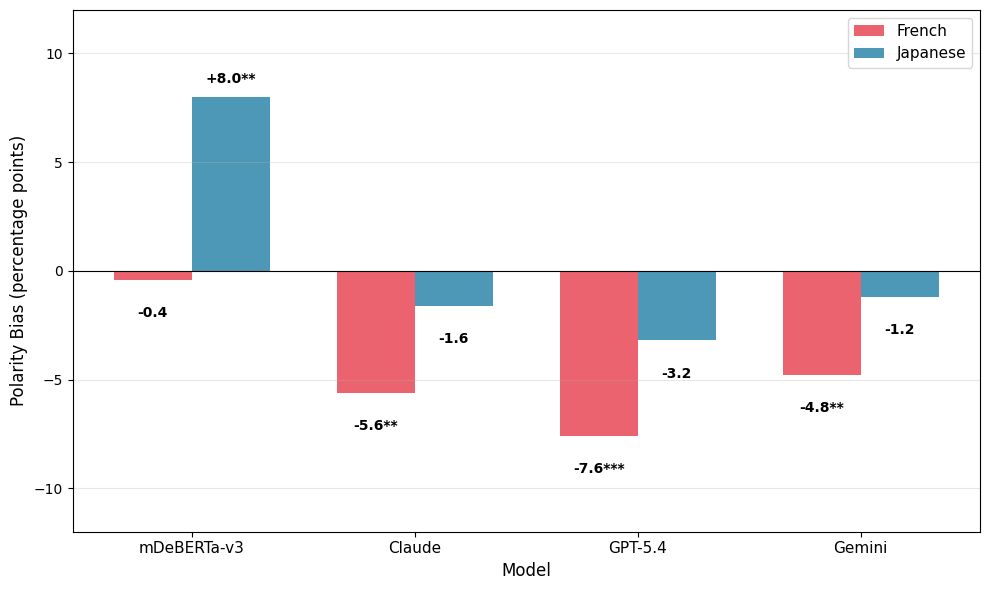

Saved: figure1_polarity_bias.png


In [15]:
# FIGURE 1 - Polarity Bias Bar Chart

def plot_polarity_bias_figure():
    """Generate Figure 1: Polarity bias by model and language."""

    models = list(model_cols.keys())

    # Calculate bias for each model-language combination
    french_bias = []
    french_sig = []
    japanese_bias = []
    japanese_sig = []

    for model_name, col in model_cols.items():
        # French
        pos_fr = df_fr[df_fr['true_label'] == 'positive']
        neg_fr = df_fr[df_fr['true_label'] == 'negative']
        diff_fr = pos_fr[col].mean() - neg_fr[col].mean()
        french_bias.append(diff_fr * 100)

        # Chi-square for significance
        cont_fr = [[pos_fr[col].sum(), len(pos_fr) - pos_fr[col].sum()],
                   [neg_fr[col].sum(), len(neg_fr) - neg_fr[col].sum()]]
        _, p_fr, _, _ = stats.chi2_contingency(cont_fr, correction=True)
        french_sig.append('***' if p_fr < 0.001 else ('**' if p_fr < 0.01 else ('*' if p_fr < 0.05 else '')))

        # Japanese
        pos_jp = df_jp[df_jp['true_label'] == 'positive']
        neg_jp = df_jp[df_jp['true_label'] == 'negative']
        diff_jp = pos_jp[col].mean() - neg_jp[col].mean()
        japanese_bias.append(diff_jp * 100)

        cont_jp = [[pos_jp[col].sum(), len(pos_jp) - pos_jp[col].sum()],
                   [neg_jp[col].sum(), len(neg_jp) - neg_jp[col].sum()]]
        _, p_jp, _, _ = stats.chi2_contingency(cont_jp, correction=True)
        japanese_sig.append('***' if p_jp < 0.001 else ('**' if p_jp < 0.01 else ('*' if p_jp < 0.05 else '')))

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))

    x = np.arange(len(models))
    width = 0.35

    # Plot bars WITHOUT error bars
    bars_fr = ax.bar(x - width/2, french_bias, width,
                     label='French', color='#E84855', alpha=0.85)
    bars_jp = ax.bar(x + width/2, japanese_bias, width,
                     label='Japanese', color='#2E86AB', alpha=0.85)

    # Add value labels with significance markers
    for i, (bar_fr, bar_jp) in enumerate(zip(bars_fr, bars_jp)):
        # French
        height_fr = bar_fr.get_height()
        offset_fr = -1.2 if height_fr < 0 else 0.5
        va_fr = 'top' if height_fr < 0 else 'bottom'
        ax.text(bar_fr.get_x() + bar_fr.get_width()/2, height_fr + offset_fr,
                f'{height_fr:+.1f}{french_sig[i]}', ha='center', va=va_fr,
                fontsize=10, fontweight='bold')

        # Japanese
        height_jp = bar_jp.get_height()
        offset_jp = 0.5 if height_jp >= 0 else -1.2
        va_jp = 'bottom' if height_jp >= 0 else 'top'
        ax.text(bar_jp.get_x() + bar_jp.get_width()/2, height_jp + offset_jp,
                f'{height_jp:+.1f}{japanese_sig[i]}', ha='center', va=va_jp,
                fontsize=10, fontweight='bold')

    # Formatting
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax.set_ylabel('Polarity Bias (percentage points)', fontsize=12)
    ax.set_xlabel('Model', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(['mDeBERTa-v3', 'Claude', 'GPT-5.4', 'Gemini'], fontsize=11)
    ax.set_ylim(-12, 12)
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    # Add annotation
    """
     ax.text(0.02, 0.98, 'Bias = Positive Acc. − Negative Acc.\n'
            'Positive: better on positive reviews\n'
            'Negative: better on negative reviews',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    """

    #plt.title('Figure 1. Sentiment Polarity Bias by Model and Language', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('figure1_polarity_bias.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: figure1_polarity_bias.png")

plot_polarity_bias_figure()

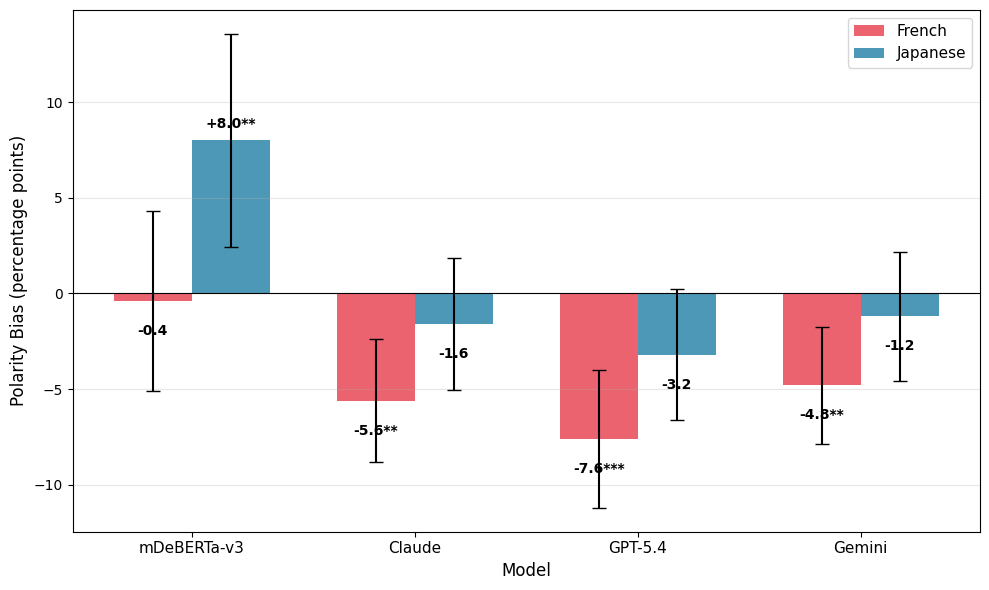

Saved: figure1_polarity_bias.png


In [16]:
# FIGURE 1 - Polarity Bias Bar Chart with CIs

def plot_polarity_bias_figure():
    """Generate Figure 1: Polarity bias by model and language."""

    models = list(model_cols.keys())

    # Calculate bias and CIs for each model-language combination
    french_bias = []
    french_ci = []
    french_sig = []
    japanese_bias = []
    japanese_ci = []
    japanese_sig = []

    for model_name, col in model_cols.items():
        # French
        pos_fr = df_fr[df_fr['true_label'] == 'positive']
        neg_fr = df_fr[df_fr['true_label'] == 'negative']
        diff_fr, ci_low_fr, ci_high_fr = accuracy_diff_ci(
            pos_fr[col].sum(), len(pos_fr),
            neg_fr[col].sum(), len(neg_fr)
        )
        french_bias.append(diff_fr * 100)
        french_ci.append((diff_fr - ci_low_fr) * 100)  # CI half-width

        # Chi-square for significance
        cont_fr = [[pos_fr[col].sum(), len(pos_fr) - pos_fr[col].sum()],
                   [neg_fr[col].sum(), len(neg_fr) - neg_fr[col].sum()]]
        _, p_fr, _, _ = stats.chi2_contingency(cont_fr, correction=True)
        french_sig.append('***' if p_fr < 0.001 else ('**' if p_fr < 0.01 else ('*' if p_fr < 0.05 else '')))

        # Japanese
        pos_jp = df_jp[df_jp['true_label'] == 'positive']
        neg_jp = df_jp[df_jp['true_label'] == 'negative']
        diff_jp, ci_low_jp, ci_high_jp = accuracy_diff_ci(
            pos_jp[col].sum(), len(pos_jp),
            neg_jp[col].sum(), len(neg_jp)
        )
        japanese_bias.append(diff_jp * 100)
        japanese_ci.append((diff_jp - ci_low_jp) * 100)

        cont_jp = [[pos_jp[col].sum(), len(pos_jp) - pos_jp[col].sum()],
                   [neg_jp[col].sum(), len(neg_jp) - neg_jp[col].sum()]]
        _, p_jp, _, _ = stats.chi2_contingency(cont_jp, correction=True)
        japanese_sig.append('***' if p_jp < 0.001 else ('**' if p_jp < 0.01 else ('*' if p_jp < 0.05 else '')))

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))

    x = np.arange(len(models))
    width = 0.35

    # Plot bars with error bars
    bars_fr = ax.bar(x - width/2, french_bias, width, yerr=french_ci, capsize=5,
                     label='French', color='#E84855', alpha=0.85)
    bars_jp = ax.bar(x + width/2, japanese_bias, width, yerr=japanese_ci, capsize=5,
                     label='Japanese', color='#2E86AB', alpha=0.85)

    # Add value labels with significance markers
    for i, (bar_fr, bar_jp) in enumerate(zip(bars_fr, bars_jp)):
        # French
        height_fr = bar_fr.get_height()
        offset_fr = -1.2 if height_fr < 0 else 0.5
        va_fr = 'top' if height_fr < 0 else 'bottom'
        ax.text(bar_fr.get_x() + bar_fr.get_width()/2, height_fr + offset_fr,
                f'{height_fr:+.1f}{french_sig[i]}', ha='center', va=va_fr,
                fontsize=10, fontweight='bold')

        # Japanese
        height_jp = bar_jp.get_height()
        offset_jp = 0.5 if height_jp >= 0 else -1.2
        va_jp = 'bottom' if height_jp >= 0 else 'top'
        ax.text(bar_jp.get_x() + bar_jp.get_width()/2, height_jp + offset_jp,
                f'{height_jp:+.1f}{japanese_sig[i]}', ha='center', va=va_jp,
                fontsize=10, fontweight='bold')

    # Formatting
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax.set_ylabel('Polarity Bias (percentage points)', fontsize=12)
    ax.set_xlabel('Model', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(['mDeBERTa-v3', 'Claude', 'GPT-5.4', 'Gemini'], fontsize=11)
    #ax.set_ylim(-12, 15)
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    # Add annotation
    """
    ax.text(0.02, 0.98, 'Bias = Positive Acc. − Negative Acc.\n'
            'Positive: better on positive reviews\n'
            'Negative: better on negative reviews',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    """

    #plt.title('Figure 1. Sentiment Polarity Bias by Model and Language', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('figure1_polarity_bias_withcis.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: figure1_polarity_bias.png")

plot_polarity_bias_figure()


In [17]:
# Oracle Ensemble Analysis

print("\n" + "=" * 70)
print("ORACLE ENSEMBLE ANALYSIS")
print("=" * 70)

for lang, df in [('French', df_fr), ('Japanese', df_jp)]:
    # Oracle: correct if ANY model is correct
    oracle = (df['mDeBERTa_correct'] | df['Claude_correct'] |
              df['ChatGPT_correct'] | df['Gemini_correct'])
    oracle_acc = oracle.mean()

    # Best single model
    accs = {
        'mDeBERTa': df['mDeBERTa_correct'].mean(),
        'Claude': df['Claude_correct'].mean(),
        'GPT-5.4': df['ChatGPT_correct'].mean(),
        'Gemini': df['Gemini_correct'].mean()
    }
    best_model = max(accs, key=accs.get)
    best_acc = accs[best_model]

    print(f"\n{lang}:")
    print(f"  Oracle ensemble accuracy: {oracle_acc:.1%}")
    print(f"  Best single model ({best_model}): {best_acc:.1%}")
    print(f"  Improvement: +{(oracle_acc - best_acc)*100:.1f}pp")



ORACLE ENSEMBLE ANALYSIS

French:
  Oracle ensemble accuracy: 98.0%
  Best single model (Gemini): 96.8%
  Improvement: +1.2pp

Japanese:
  Oracle ensemble accuracy: 98.0%
  Best single model (Gemini): 96.2%
  Improvement: +1.8pp


In [ ]:
# Inter-Model Agreement Analysis

print("\n" + "=" * 70)
print("INTER-MODEL AGREEMENT ANALYSIS")
print("=" * 70)

# Combine datasets
df_all = pd.concat([df_fr, df_jp], ignore_index=True)

# LLM inter-agreement (based on predictions)
print("\nLLM Inter-Agreement (prediction match rate):")
llm_pairs = [
    ('Claude', 'ChatGPT', 'Claude_pred', 'ChatGPT_pred'),
    ('Claude', 'Gemini', 'Claude_pred', 'Gemini_pred'),
    ('ChatGPT', 'Gemini', 'ChatGPT_pred', 'Gemini_pred'),
]
for m1, m2, p1, p2 in llm_pairs:
    agreement = (df_all[p1] == df_all[p2]).mean()
    print(f"  {m1} vs {m2}: {agreement:.1%}")

# mDeBERTa vs LLMs
print("\nmDeBERTa vs LLM Agreement:")
for llm_pred in ['Claude_pred', 'ChatGPT_pred', 'Gemini_pred']:
    agreement = (df_all['mDeBERTa_pred'] == df_all[llm_pred]).mean()
    llm_name = llm_pred.replace('_pred', '')
    print(f"  mDeBERTa vs {llm_name}: {agreement:.1%}")

# Error overlap
print("\nmDeBERTa Error Overlap with LLMs:")
mdeberta_errors = df_all[df_all['mDeBERTa_correct'] == False]
for llm_col in ['Claude_correct', 'ChatGPT_correct', 'Gemini_correct']:
    overlap = (mdeberta_errors[llm_col] == False).mean()
    llm_name = llm_col.replace('_correct', '')
    print(f"  Overlap with {llm_name}: {overlap:.1%}")



INTER-MODEL AGREEMENT ANALYSIS

LLM Inter-Agreement (prediction match rate):
  Claude vs ChatGPT: 98.3%
  Claude vs Gemini: 98.5%
  ChatGPT vs Gemini: 98.2%

mDeBERTa vs LLM Agreement:
  mDeBERTa vs Claude: 91.3%
  mDeBERTa vs ChatGPT: 90.6%
  mDeBERTa vs Gemini: 91.4%

mDeBERTa Error Overlap with LLMs:
  Overlap with Claude: 24.7%
  Overlap with ChatGPT: 23.7%
  Overlap with Gemini: 23.7%


In [18]:
# Error Analysis Verification

print("\n" + "=" * 70)
print("ERROR ANALYSIS VERIFICATION")
print("=" * 70)

# French: Check for negative markers in LLM false negatives
negative_markers_fr = ['mais', 'problème', 'malheureusement', 'dommage', 'déçu',
                       'contre', 'helas', 'cependant']

print("\nFrench LLM Errors (positive reviews with negative markers):")
fr_pos = df_fr[df_fr['true_label'] == 'positive']

for model, pred_col in [('Claude', 'Claude_pred'), ('GPT-5.4', 'ChatGPT_pred'), ('Gemini', 'Gemini_pred')]:
    errors = fr_pos[fr_pos[pred_col] == 'negative']
    count_with_markers = sum(
        any(marker in text.lower() for marker in negative_markers_fr)
        for text in errors['raw_text']
    )
    pct = count_with_markers / len(errors) * 100 if len(errors) > 0 else 0
    print(f"  {model}: {count_with_markers}/{len(errors)} ({pct:.0f}%)")

# Japanese: Check for softening patterns in mDeBERTa false positives
softening_patterns_jp = ['が', 'けど', 'ですが', 'ました', 'でした',
                         '良い', '良かった', '気に入',
                         '満足', '使いやす', '好き']

print("\nJapanese mDeBERTa Errors (negative reviews with softening language):")
jp_neg = df_jp[df_jp['true_label'] == 'negative']
mdeberta_jp_errors = jp_neg[jp_neg['mDeBERTa_correct'] == False]

count_with_softening = sum(
    any(pattern in text for pattern in softening_patterns_jp)
    for text in mdeberta_jp_errors['raw_text']
)
pct = count_with_softening / len(mdeberta_jp_errors) * 100 if len(mdeberta_jp_errors) > 0 else 0
print(f"  mDeBERTa: {count_with_softening}/{len(mdeberta_jp_errors)} ({pct:.0f}%)")

print("\nLLM Correctness on mDeBERTa's Japanese Errors:")
for llm_col in ['Claude_correct', 'ChatGPT_correct', 'Gemini_correct']:
    llm_correct = mdeberta_jp_errors[llm_col].mean() * 100
    llm_name = llm_col.replace('_correct', '')
    print(f"  {llm_name}: {llm_correct:.1f}%")


ERROR ANALYSIS VERIFICATION

French LLM Errors (positive reviews with negative markers):
  Claude: 11/16 (69%)
  GPT-5.4: 14/21 (67%)
  Gemini: 11/14 (79%)

Japanese mDeBERTa Errors (negative reviews with softening language):
  mDeBERTa: 38/39 (97%)

LLM Correctness on mDeBERTa's Japanese Errors:
  Claude: 82.1%
  ChatGPT: 84.6%
  Gemini: 82.1%


In [19]:

# Save Updated Statistical Summary

def generate_full_summary(df_fr, df_jp):
    """Generate comprehensive polarity bias summary for CSV export."""
    rows = []
    for model_name, col in model_cols.items():
        for lang, df in [('French', df_fr), ('Japanese', df_jp)]:
            pos = df[df['true_label'] == 'positive']
            neg = df[df['true_label'] == 'negative']

            pos_acc = pos[col].mean()
            neg_acc = neg[col].mean()

            contingency = [
                [pos[col].sum(), len(pos) - pos[col].sum()],
                [neg[col].sum(), len(neg) - neg[col].sum()]
            ]
            chi2, p, _, _ = stats.chi2_contingency(contingency, correction=True)
            v = cramers_v(contingency)
            diff, ci_low, ci_high = accuracy_diff_ci(
                pos[col].sum(), len(pos), neg[col].sum(), len(neg)
            )

            rows.append({
                'Model': model_name,
                'Language': lang,
                'Positive Accuracy': f'{pos_acc:.1%}',
                'Negative Accuracy': f'{neg_acc:.1%}',
                'Bias (pp)': f'{diff*100:+.1f}',
                '95% CI Lower': f'{ci_low*100:+.1f}',
                '95% CI Upper': f'{ci_high*100:+.1f}',
                'Chi-Square': f'{chi2:.2f}',
                'P-Value': f'{p:.4f}',
                "Cramér's V": f'{v:.3f}',
                'Significance': 'Yes' if p < 0.05 else 'No'
            })

    return pd.DataFrame(rows)

summary_df = generate_full_summary(df_fr, df_jp)
summary_df.to_csv('polarity_bias_summary.csv', index=False)
print("\n" + "=" * 70)
print("SAVED: polarity_bias_summary.csv")
print("=" * 70)
print(summary_df.to_string(index=False))


SAVED: polarity_bias_summary.csv
          Model Language Positive Accuracy Negative Accuracy Bias (pp) 95% CI Lower 95% CI Upper Chi-Square P-Value Cramér's V Significance
    mDeBERTa-v3   French             92.0%             92.4%      -0.4         -5.1         +4.3       0.00  1.0000      0.000           No
    mDeBERTa-v3 Japanese             92.4%             84.4%      +8.0         +2.4        +13.6       7.04  0.0080      0.119          Yes
Claude Opus 4.6   French             93.6%             99.2%      -5.6         -8.8         -2.4       9.74  0.0018      0.140          Yes
Claude Opus 4.6 Japanese             95.2%             96.8%      -1.6         -5.0         +1.8       0.47  0.4936      0.031           No
        GPT-5.4   French             91.6%             99.2%      -7.6        -11.2         -4.0      14.77  0.0001      0.172          Yes
        GPT-5.4 Japanese             94.4%             97.6%      -3.2         -6.6         +0.2       2.55  0.1101      0.071